# Component 1: Hybrid Multi-Algorithm Recommendation Engine

This notebook runs the full Component 1 implementation in Google Colab.

Algorithms:
- TF-IDF Content-Based Filtering
- BERT / Sentence Transformer semantic matching
- Custom Credibility-Based Collaborative Filtering
- Hybrid fusion: **0.35 CF + 0.30 TF-IDF + 0.35 BERT**

Datasets needed:
1. Provider dataset
2. User request dataset
3. User interaction dataset

Review dataset is not used here because it belongs to Component 4.

In [2]:
!pip install -q sentence-transformers openpyxl

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from datetime import datetime
from typing import Optional
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

print("Libraries imported successfully")

Libraries imported successfully


## 1. Upload the three datasets

In [5]:
from google.colab import files
uploaded = files.upload()

print("Uploaded files:")
for name in uploaded.keys():
    print("-", name)

Saving SL_User_Interaction_Dataset_100000.csv to SL_User_Interaction_Dataset_100000 (1).csv
Saving SL_User_Request_Dataset_20000.csv to SL_User_Request_Dataset_20000 (1).csv
Saving SL_Provider_Dataset_10000_Research_Grade.xlsx to SL_Provider_Dataset_10000_Research_Grade.xlsx
Uploaded files:
- SL_User_Interaction_Dataset_100000 (1).csv
- SL_User_Request_Dataset_20000 (1).csv
- SL_Provider_Dataset_10000_Research_Grade.xlsx


In [6]:
# Change these names if your files are named differently.
PROVIDER_FILE = "SL_Provider_Dataset_10000_Research_Grade.xlsx"
REQUEST_FILE = "SL_User_Request_Dataset_20000.csv"
INTERACTION_FILE = "SL_User_Interaction_Dataset_100000.csv"

provider_df = pd.read_excel(PROVIDER_FILE)
request_df = pd.read_csv(REQUEST_FILE)
interaction_df = pd.read_csv(INTERACTION_FILE)

print("=" * 70)
print("DATASET LOADING SUMMARY")
print("=" * 70)
print("Provider dataset shape:", provider_df.shape)
print("Request dataset shape:", request_df.shape)
print("Interaction dataset shape:", interaction_df.shape)

print("\nProvider columns:", list(provider_df.columns))
print("\nRequest columns:", list(request_df.columns))
print("\nInteraction columns:", list(interaction_df.columns))

DATASET LOADING SUMMARY
Provider dataset shape: (10000, 12)
Request dataset shape: (20000, 8)
Interaction dataset shape: (100000, 8)

Provider columns: ['provider_id', 'provider_name', 'category', 'district', 'city', 'experience_years', 'rating', 'review_count', 'booking_success_rate', 'interaction_count', 'skills', 'description']

Request columns: ['request_id', 'user_id', 'request_text', 'category', 'district', 'city', 'urgency', 'created_at']

Interaction columns: ['interaction_id', 'user_id', 'provider_id', 'category', 'interaction_type', 'rating', 'booking_status', 'timestamp']


## 2. Data cleaning and preprocessing

In [7]:
def clean_text(text):
    if pd.isna(text):
        return ""
    return str(text).lower().strip()

provider_df["category_clean"] = provider_df["category"].apply(clean_text)
provider_df["skills_clean"] = provider_df["skills"].apply(clean_text)
provider_df["description_clean"] = provider_df["description"].apply(clean_text)

provider_df["combined_text"] = (
    provider_df["category_clean"] + " " +
    provider_df["skills_clean"] + " " +
    provider_df["description_clean"]
)

request_df["request_text_clean"] = request_df["request_text"].apply(clean_text)

interaction_df["booking_status"] = interaction_df["booking_status"].fillna("").astype(str).str.lower()
interaction_df["rating"] = pd.to_numeric(interaction_df["rating"], errors="coerce")

print("Preprocessing completed")
print(provider_df[["provider_id", "category", "skills", "description", "combined_text"]].head())

Preprocessing completed
  provider_id category                                     skills  \
0      P00001   Masons    brick laying, concrete work, plastering   
1      P00002   Masons  brick laying, plastering, foundation work   
2      P00003   Masons  plastering, foundation work, brick laying   
3      P00004   Masons  plastering, foundation work, brick laying   
4      P00005   Masons    concrete work, plastering, brick laying   

                                         description  \
0  Experienced masons provider in Batticaloa spec...   
1  Experienced masons provider in Chavakachcheri ...   
2  Experienced masons provider in Kekirawa specia...   
3  Experienced masons provider in Peradeniya spec...   
4  Experienced masons provider in Katugastota spe...   

                                       combined_text  
0  masons brick laying, concrete work, plastering...  
1  masons brick laying, plastering, foundation wo...  
2  masons plastering, foundation work, brick layi...  
3  m

## 3. Create interaction metrics for the CF component

In [8]:
interaction_df["booking_success_binary"] = np.where(
    interaction_df["booking_status"] == "completed", 1, 0
)

interaction_metrics = interaction_df.groupby("provider_id").agg(
    avg_rating=("rating", "mean"),
    interaction_count=("interaction_id", "count"),
    booking_success_rate=("booking_success_binary", "mean")
).reset_index()

# List of columns that will be provided by interaction_metrics
# and might exist in provider_df from previous operations or original data.
cols_to_drop_before_merge = ['avg_rating', 'booking_success_rate', 'interaction_count']

# Drop these columns from provider_df if they exist, to prevent merge conflicts
# and ensure we use the newly calculated metrics from interaction_metrics.
provider_df_pre_merge = provider_df.drop(columns=cols_to_drop_before_merge, errors='ignore')

# Perform a left merge to add interaction metrics to provider_df_pre_merge
provider_df = provider_df_pre_merge.merge(interaction_metrics, on="provider_id", how="left")

# Fill NaN values for 'avg_rating' using the original 'rating' column
provider_df["avg_rating"] = provider_df["avg_rating"].fillna(provider_df["rating"])

# Fill NaNs for interaction_count and booking_success_rate (for providers with no interactions)
provider_df["interaction_count"] = provider_df["interaction_count"].fillna(0)
provider_df["booking_success_rate"] = provider_df["booking_success_rate"].fillna(0)

print("Interaction metrics created")
print(provider_df[["provider_id", "avg_rating", "interaction_count", "booking_success_rate"]].head())

Interaction metrics created
  provider_id  avg_rating  interaction_count  booking_success_rate
0      P00001    4.142857               14.0              0.285714
1      P00002    4.000000               12.0              0.250000
2      P00003    3.714286               13.0              0.384615
3      P00004    3.777778               16.0              0.375000
4      P00005    3.666667                6.0              0.333333


## 4. TF-IDF Content-Based Filtering

In [9]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=1,
    max_df=0.95,
    ngram_range=(1, 2),
    stop_words="english"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(provider_df["combined_text"])

def compute_tfidf_scores(query: str) -> np.ndarray:
    query_vector = tfidf_vectorizer.transform([clean_text(query)])
    scores = cosine_similarity(query_vector, tfidf_matrix)[0]
    return scores

test_query = request_df["request_text"].iloc[0]
tfidf_scores = compute_tfidf_scores(test_query)

print("TF-IDF fitted successfully")
print("Vocabulary size:", len(tfidf_vectorizer.get_feature_names_out()))
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Test query:", test_query)
print("Score range:", tfidf_scores.min(), tfidf_scores.max())

TF-IDF fitted successfully
Vocabulary size: 662
TF-IDF matrix shape: (10000, 662)
Test query: Need CCTV technician for DVR configuration in Kottawa, Colombo
Score range: 0.0 0.5177552379883936


## 5. BERT / Sentence Transformer Semantic Matching

In [10]:
bert_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

provider_embeddings = bert_model.encode(
    provider_df["combined_text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

def compute_bert_scores(query: str) -> np.ndarray:
    query_embedding = bert_model.encode(
        [clean_text(query)],
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    scores = cosine_similarity(query_embedding, provider_embeddings)[0]
    return scores

bert_scores = compute_bert_scores(test_query)

print("BERT embeddings generated")
print("Provider embeddings shape:", provider_embeddings.shape)
print("BERT score range:", bert_scores.min(), bert_scores.max())

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

BERT embeddings generated
Provider embeddings shape: (10000, 384)
BERT score range: 0.09412642 0.8519924


## 6. Custom Credibility-Based Collaborative Filtering

In [11]:
provider_credibility = provider_df.copy()

provider_credibility["credibility_score"] = (
    (provider_credibility["avg_rating"] / 5.0) * 0.50 +
    provider_credibility["booking_success_rate"] * 0.30 +
    np.tanh(provider_credibility["interaction_count"] / 100) * 0.20
)

credibility_scaler = MinMaxScaler(feature_range=(0, 1))
provider_credibility["credibility_score"] = credibility_scaler.fit_transform(
    provider_credibility[["credibility_score"]]
).flatten()

provider_credibility["credibility_score"] = provider_credibility["credibility_score"].fillna(0.5)

user_preferences = interaction_df.groupby("user_id")["provider_id"].apply(list).to_dict()

def compute_cf_scores(user_id) -> np.ndarray:
    cf_scores = provider_credibility["credibility_score"].values.copy()

    if user_id in user_preferences:
        user_history = user_preferences[user_id]

        for prov_id in user_history:
            provider_idx = provider_df.index[provider_df["provider_id"] == prov_id].tolist()

            if len(provider_idx) > 0:
                cf_scores[provider_idx[0]] *= 1.20

    cf_scores = np.clip(cf_scores, 0, 1)
    cf_scores = np.nan_to_num(cf_scores, nan=0.5)
    return cf_scores

test_user_id = interaction_df["user_id"].iloc[0]
cf_scores = compute_cf_scores(test_user_id)

print("Custom CF scores computed")
print("Test user:", test_user_id)
print("CF score range:", cf_scores.min(), cf_scores.max())
print("Mean CF score:", cf_scores.mean())

Custom CF scores computed
Test user: U03894
CF score range: 0.0 0.9999999999999999
Mean CF score: 0.5572621570720052


## 7. Hybrid score fusion

In [12]:
WEIGHTS = {
    "tfidf": 0.30,
    "bert": 0.35,
    "cf": 0.35
}

def normalize_scores(scores: np.ndarray) -> np.ndarray:
    scores = np.nan_to_num(scores, nan=0.0)
    min_score = np.min(scores)
    max_score = np.max(scores)

    if max_score == min_score:
        return np.ones_like(scores) * 0.5

    return (scores - min_score) / (max_score - min_score)

def combine_scores(tfidf_scores, bert_scores, cf_scores):
    tfidf_norm = normalize_scores(tfidf_scores)
    bert_norm = normalize_scores(bert_scores)
    cf_norm = normalize_scores(cf_scores)

    hybrid_scores = (
        WEIGHTS["tfidf"] * tfidf_norm +
        WEIGHTS["bert"] * bert_norm +
        WEIGHTS["cf"] * cf_norm
    )
    return hybrid_scores

hybrid_scores = combine_scores(tfidf_scores, bert_scores, cf_scores)

print("Hybrid score fusion completed")
print("Formula: Hybrid Score = 0.35*CF + 0.30*TF-IDF + 0.35*BERT")
print("Hybrid score range:", hybrid_scores.min(), hybrid_scores.max())

Hybrid score fusion completed
Formula: Hybrid Score = 0.35*CF + 0.30*TF-IDF + 0.35*BERT
Hybrid score range: 0.022220151981023444 0.9002994800683458


## 8. Rank Top-20 providers

In [13]:
def rank_providers(
    query: str,
    user_id,
    top_k: int = 20,
    category: Optional[str] = None,
    district: Optional[str] = None,
    city: Optional[str] = None,
    min_rating: float = 0.0
) -> pd.DataFrame:

    tfidf_scores = compute_tfidf_scores(query)
    bert_scores = compute_bert_scores(query)
    cf_scores = compute_cf_scores(user_id)

    hybrid_scores = combine_scores(tfidf_scores, bert_scores, cf_scores)

    results_df = provider_df.copy()
    results_df["tfidf_score"] = normalize_scores(tfidf_scores)
    results_df["bert_score"] = normalize_scores(bert_scores)
    results_df["cf_score"] = normalize_scores(cf_scores)
    results_df["hybrid_score"] = hybrid_scores

    if category:
        results_df = results_df[results_df["category"].str.lower() == category.lower()]

    if district:
        results_df = results_df[results_df["district"].str.lower() == district.lower()]

    if city:
        results_df = results_df[results_df["city"].str.lower() == city.lower()]

    if min_rating > 0:
        results_df = results_df[results_df["rating"] >= min_rating]

    results_df = results_df.sort_values("hybrid_score", ascending=False)
    results_df = results_df.head(top_k).reset_index(drop=True)

    output_columns = [
        "provider_id", "provider_name", "category", "district", "city",
        "skills", "description", "experience_years", "rating", "review_count",
        "booking_success_rate", "interaction_count",
        "hybrid_score", "tfidf_score", "bert_score", "cf_score"
    ]

    return results_df[[col for col in output_columns if col in results_df.columns]]

sample_request = request_df.iloc[0]

top20 = rank_providers(
    query=sample_request["request_text"],
    user_id=sample_request["user_id"],
    top_k=20
)

print("Sample request:", sample_request["request_text"])
top20.head(10)

Sample request: Need CCTV technician for DVR configuration in Kottawa, Colombo


,provider_id,provider_name,category,district,city,skills,description,experience_years,rating,review_count,booking_success_rate,interaction_count,hybrid_score,tfidf_score,bert_score,cf_score
0,P07716,Trusted CCTV Solutions,CCTV,Kalutara,Kalutara,"network setup, camera installation, DVR config...",Experienced cctv provider in Kalutara speciali...,14,4.0,65,0.444444,9.0,0.900299,0.983842,0.976433,0.752558
1,P07747,Ajith Wijesinghe,CCTV,Kurunegala,Kuliyapitiya,"DVR configuration, network setup, security mon...",Experienced cctv provider in Kuliyapitiya spec...,15,3.9,667,0.600000,5.0,0.895471,0.958703,0.947832,0.788910
2,P07305,Chamara Samarasinghe,CCTV,Batticaloa,Kattankudy,"DVR configuration, camera installation, networ...",Experienced cctv provider in Kattankudy specia...,2,4.1,257,0.600000,10.0,0.892001,0.980593,0.959490,0.748576
3,P07472,Sunil Ekanayake,CCTV,Kurunegala,Kuliyapitiya,"DVR configuration, camera installation, networ...",Experienced cctv provider in Kuliyapitiya spec...,21,3.3,448,0.357143,14.0,0.889186,0.980760,0.989811,0.710070
4,P07546,Metro CCTV Solutions,CCTV,Jaffna,Chavakachcheri,"DVR configuration, camera installation, networ...",Experienced cctv provider in Chavakachcheri sp...,6,3.9,694,0.428571,7.0,0.882080,0.981087,0.958358,0.720940
5,P07385,Lanka CCTV Solutions,CCTV,Kandy,Katugastota,"network setup, camera installation, DVR config...",Experienced cctv provider in Katugastota speci...,2,3.8,500,0.375000,8.0,0.880046,0.979351,0.983762,0.691213
6,P07445,City CCTV Maintenance,CCTV,Kurunegala,Kuliyapitiya,"DVR configuration, camera installation, networ...",Experienced cctv provider in Kuliyapitiya spec...,16,3.4,23,0.428571,7.0,0.879619,0.980760,0.989811,0.682736
7,P07473,Sanjeewa Ekanayake,CCTV,Gampaha,Kiribathgoda,"DVR configuration, network setup, camera insta...",Experienced cctv provider in Kiribathgoda spec...,7,4.9,85,0.400000,10.0,0.877870,0.982797,0.972488,0.693316
8,P07784,Prime CCTV Care,CCTV,Galle,Galle,"DVR configuration, network setup, camera insta...",Experienced cctv provider in Galle specializin...,5,3.7,675,0.545455,11.0,0.877493,0.986524,0.902865,0.758666
9,P07477,Sunil Samarasinghe,CCTV,Batticaloa,Batticaloa,"network setup, camera installation, DVR config...",Experienced cctv provider in Batticaloa specia...,2,4.8,64,0.500000,4.0,0.876376,0.984740,0.940675,0.719193


## 9. Test with Sinhala-English mixed requests

In [14]:
test_requests = [
    "AC eka cooling naha compressor noise enawa Colombo",
    "gey pipe leak ekak fix karanna plumber one Kandy",
    "house wiring issue ekak thiyenawa electrician one",
    "sofa cushion repair karanna one Gampaha",
    "CCTV camera installation karanna one"
]

for q in test_requests:
    print("=" * 100)
    print("QUERY:", q)
    print("=" * 100)

    results = rank_providers(q, test_user_id, top_k=5)
    display(results[[
        "provider_name", "category", "district", "city",
        "hybrid_score", "tfidf_score", "bert_score", "cf_score", "rating"
    ]])

QUERY: AC eka cooling naha compressor noise enawa Colombo


,provider_name,category,district,city,hybrid_score,tfidf_score,bert_score,cf_score,rating
0,Chamara Karunaratne,A/C,Kandy,Gampola,0.871635,0.985119,0.904042,0.741957,3.8
1,Best A/C Engineering,A/C,Kurunegala,Kurunegala,0.868666,0.987147,0.940981,0.694795,4.1
2,Gayan Perera,A/C,Anuradhapura,Kekirawa,0.864822,0.988764,0.975448,0.647960,4.4
3,Amila Jayasinghe,A/C,Kalutara,Panadura,0.862338,0.987477,0.926673,0.690741,4.0
4,Nadeesha Gunawardena,A/C,Gampaha,Kiribathgoda,0.856426,0.987151,0.954905,0.645896,4.9


QUERY: gey pipe leak ekak fix karanna plumber one Kandy


,provider_name,category,district,city,hybrid_score,tfidf_score,bert_score,cf_score,rating
0,Mahesh Gunawardena,Plumbers,Anuradhapura,Kekirawa,0.910450,0.972132,0.994440,0.773591,4.9
1,Ajith Jayasinghe,Plumbers,Batticaloa,Kattankudy,0.896151,0.979996,0.972205,0.748229,4.2
2,Sunil Samarasinghe,Plumbers,Kandy,Gampola,0.884731,0.987907,0.996071,0.684953,4.3
3,Metro Plumbers Maintenance,Plumbers,Kalutara,Panadura,0.882069,0.991606,0.953919,0.716331,3.5
4,Saman Perera,Plumbers,Kalutara,Panadura,0.880006,0.999138,0.863041,0.794856,4.4


QUERY: house wiring issue ekak thiyenawa electrician one


,provider_name,category,district,city,hybrid_score,tfidf_score,bert_score,cf_score,rating
0,Elite Electricians Engineering,Electricians,Galle,Hikkaduwa,0.898319,0.991436,0.991913,0.724909,4.6
1,Best Electricians Services,Electricians,Gampaha,Kadawatha,0.891789,0.980858,0.910690,0.796542,4.6
2,Royal Electricians Services,Electricians,Jaffna,Chavakachcheri,0.887181,0.987068,0.989761,0.698984,4.8
3,Ajith Madushan,Electricians,Galle,Hikkaduwa,0.883572,0.982541,0.981617,0.700697,4.1
4,Roshan Bandara,Electricians,Kandy,Gampola,0.878534,0.993422,0.910072,0.748520,4.4


QUERY: sofa cushion repair karanna one Gampaha


,provider_name,category,district,city,hybrid_score,tfidf_score,bert_score,cf_score,rating
0,Gayan Ekanayake,Cushion Works,Matara,Weligama,0.927394,0.912341,0.867692,1.000000,3.3
1,Chamara Bandara,Cushion Works,Jaffna,Chavakachcheri,0.892114,0.971069,0.964008,0.752546,3.5
2,Dilshan Silva,Cushion Works,Colombo,Maharagama,0.891301,0.963443,0.976631,0.744136,4.2
3,Gayan Silva,Cushion Works,Kandy,Katugastota,0.889302,0.967177,0.934971,0.776882,3.6
4,Tharindu Perera,Cushion Works,Gampaha,Kadawatha,0.881863,0.970590,0.963031,0.724642,3.8


QUERY: CCTV camera installation karanna one


,provider_name,category,district,city,hybrid_score,tfidf_score,bert_score,cf_score,rating
0,Metro CCTV Solutions,CCTV,Galle,Ambalangoda,0.930914,0.995748,0.955264,0.850992,4.9
1,Pradeep Madushan,CCTV,Kalutara,Kalutara,0.877103,0.970156,0.988744,0.685701,4.3
2,Gayan Ekanayake,CCTV,Kandy,Peradeniya,0.875152,0.993981,0.930371,0.718080,4.2
3,Trusted CCTV Works,CCTV,Kalutara,Kalutara,0.871969,0.997212,0.937604,0.698984,4.4
4,Gayan Madushan,CCTV,Matara,Matara,0.870222,0.970567,0.973914,0.680521,3.9


In [19]:
# ============================================================
# Robust Evaluation Dataset from User Request Dataset
# This avoids overfitting to a few hand-written queries
# ============================================================

num_eval_queries = 500

eval_request_df = request_df.sample(
    n=min(num_eval_queries, len(request_df)),
    random_state=42
).reset_index(drop=True)

QUERY_RELEVANCE = {
    row["request_text"]: [row["category"]]
    for _, row in eval_request_df.iterrows()
}

print(f"Created robust QUERY_RELEVANCE with {len(QUERY_RELEVANCE)} queries")
print("Sample ground-truth labels:")

for i, (q, cat) in enumerate(list(QUERY_RELEVANCE.items())[:10], 1):
    print(f"{i}. {q}  -->  {cat}")

Created robust QUERY_RELEVANCE with 439 queries
Sample ground-truth labels:
1. Ja-Ela, Gampaha home deep cleaning service ekak one  -->  ['Cleaners']
2. Kottawa, Colombo gey foundation concrete work ekak karanna one  -->  ['Masons']
3. Nallur, Jaffna dining table eka repair karanna one  -->  ['Carpenters']
4. Water system repair karanna plumber kenek one near Kattankudy, Batticaloa  -->  ['Plumbers']
5. Kiribathgoda, Gampaha gey tile design work ekak one  -->  ['Tile']
6. Mihintale, Anuradhapura sofa cushion repair karanna one  -->  ['Cushion Works']
7. Need AC technician for gas refill and service in Chavakachcheri, Jaffna  -->  ['A/C']
8. AC compressor repair and cooling diagnostics needed near Kurunegala, Kurunegala  -->  ['A/C']
9. Need CCTV technician for DVR configuration in Galle, Galle  -->  ['CCTV']
10. Surface preparation and spray painting karanna one near Kundasale, Kandy  -->  ['Painters']


## 10. Evaluation: Precision@K and NDCG@K

In [20]:


def precision_at_k(ranked_df, relevant_categories, k):
    return ranked_df.head(k)["category"].isin(relevant_categories).mean()

def ndcg_at_k(ranked_df, relevant_categories, k):
    rel = ranked_df.head(k)["category"].isin(relevant_categories).astype(int).values
    dcg = sum(r / np.log2(i + 2) for i, r in enumerate(rel))

    total_relevant = provider_df["category"].isin(relevant_categories).sum()
    idcg = sum(1 / np.log2(i + 2) for i in range(min(total_relevant, k)))

    return dcg / idcg if idcg > 0 else 0

K_VALUES = [5, 10, 20]
eval_rows = []

for query, relevant_categories in QUERY_RELEVANCE.items():
    ranked = rank_providers(query, test_user_id, top_k=100)

    row = {
        "query": query,
        "relevant_category": ",".join(relevant_categories)
    }

    for k in K_VALUES:
        row[f"Precision@{k}"] = precision_at_k(ranked, relevant_categories, k)
        row[f"NDCG@{k}"] = ndcg_at_k(ranked, relevant_categories, k)

    eval_rows.append(row)

eval_df = pd.DataFrame(eval_rows)
display(eval_df)

print("Average results:")
display(eval_df[[c for c in eval_df.columns if "Precision" in c or "NDCG" in c]].mean())

,query,relevant_category,Precision@5,NDCG@5,Precision@10,NDCG@10,Precision@20,NDCG@20
0,"Ja-Ela, Gampaha home deep cleaning service eka...",Cleaners,1.0,1.0,1.0,1.000000,1.0,1.000000
1,"Kottawa, Colombo gey foundation concrete work ...",Masons,1.0,1.0,1.0,1.000000,1.0,1.000000
2,"Nallur, Jaffna dining table eka repair karanna...",Carpenters,0.0,0.0,0.0,0.000000,0.0,0.000000
3,Water system repair karanna plumber kenek one ...,Plumbers,1.0,1.0,1.0,1.000000,1.0,1.000000
4,"Kiribathgoda, Gampaha gey tile design work eka...",Tile,1.0,1.0,1.0,1.000000,1.0,1.000000
...,...,...,...,...,...,...,...,...
434,Generator wiring and power issue check karanna...,Electricians,1.0,1.0,1.0,1.000000,1.0,1.000000
435,"Chavakachcheri, Jaffna security monitoring sys...",CCTV,1.0,1.0,1.0,1.000000,1.0,1.000000
436,washing machine spin karanne na technician one...,Technicians,1.0,1.0,0.9,0.930569,0.9,0.918835
437,"Hikkaduwa, Galle house wiring issue ekak thiye...",Electricians,1.0,1.0,1.0,1.000000,1.0,1.000000


Average results:


,0
Precision@5,0.948975
NDCG@5,0.949641
Precision@10,0.948292
NDCG@10,0.948974
Precision@20,0.944191
NDCG@20,0.945781


## 11. Compare TF-IDF only, BERT only, CF only, and Hybrid

In [21]:
METHODS = {
    "TF-IDF Only": {"tfidf": 1.0, "bert": 0.0, "cf": 0.0},
    "BERT Only": {"tfidf": 0.0, "bert": 1.0, "cf": 0.0},
    "CF Only": {"tfidf": 0.0, "bert": 0.0, "cf": 1.0},
    "Hybrid": WEIGHTS.copy()
}

comparison_rows = []

for method_name, w in METHODS.items():
    p10_list = []
    ndcg10_list = []

    for query, relevant_categories in QUERY_RELEVANCE.items():
        tfidf_s = normalize_scores(compute_tfidf_scores(query))
        bert_s = normalize_scores(compute_bert_scores(query))
        cf_s = normalize_scores(compute_cf_scores(test_user_id))

        score = (
            w["tfidf"] * tfidf_s +
            w["bert"] * bert_s +
            w["cf"] * cf_s
        )

        tmp = provider_df[["provider_id", "category"]].copy()
        tmp["score"] = score
        tmp = tmp.sort_values("score", ascending=False).reset_index(drop=True)

        p10_list.append(precision_at_k(tmp, relevant_categories, 10))
        ndcg10_list.append(ndcg_at_k(tmp, relevant_categories, 10))

    comparison_rows.append({
        "method": method_name,
        "Precision@10": np.mean(p10_list),
        "NDCG@10": np.mean(ndcg10_list)
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,method,Precision@10,NDCG@10
0,TF-IDF Only,0.937813,0.941172
1,BERT Only,0.944191,0.945058
2,CF Only,0.065148,0.063263
3,Hybrid,0.948292,0.948974


Evaluation queries: 439
Pre-caching component scores...
Scores cached for 439 evaluation queries


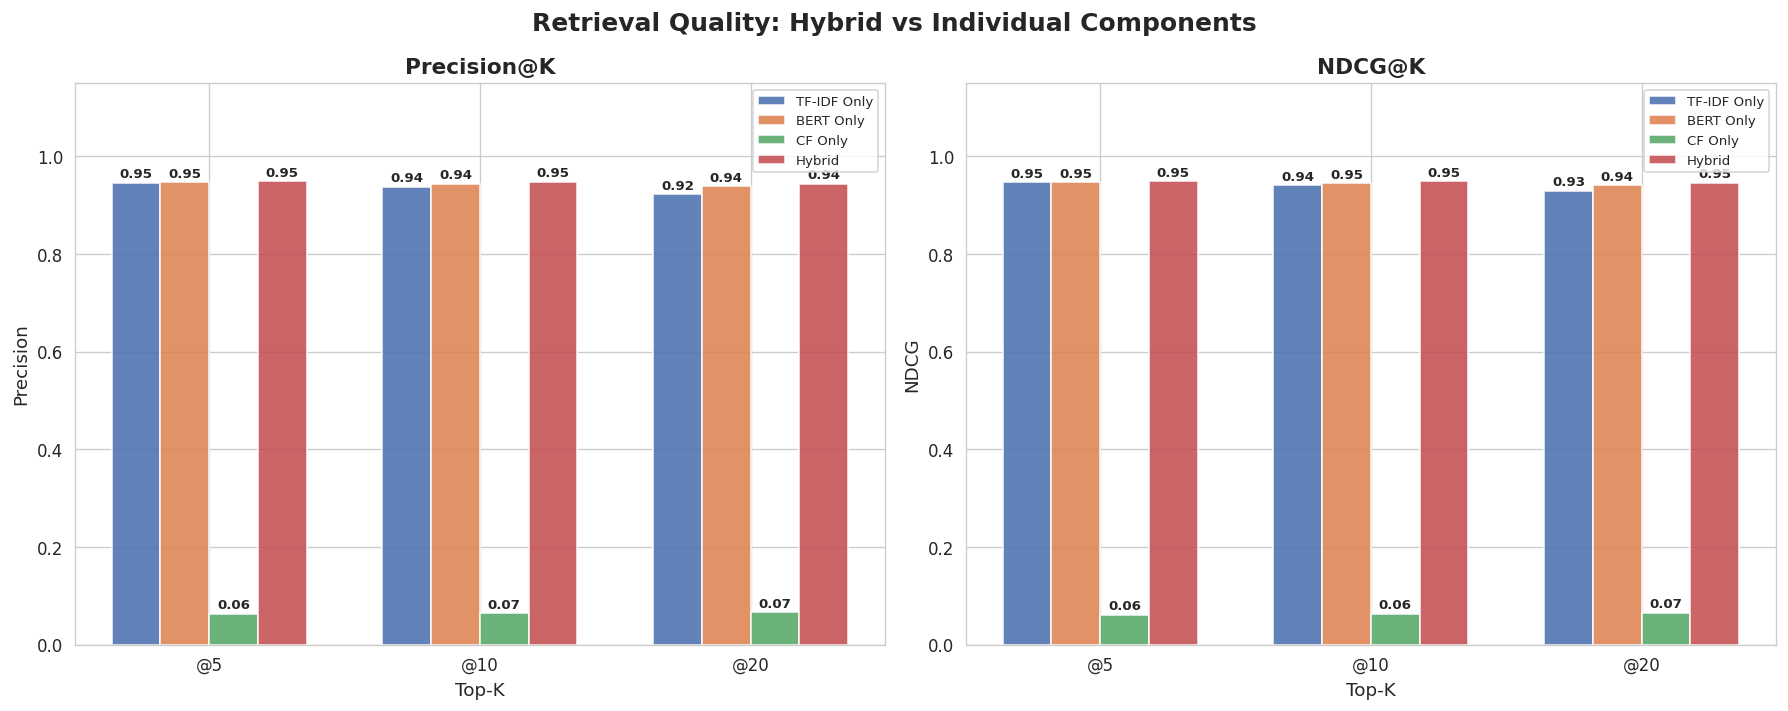

Visualization Query: Ja-Ela, Gampaha home deep cleaning service ekak one


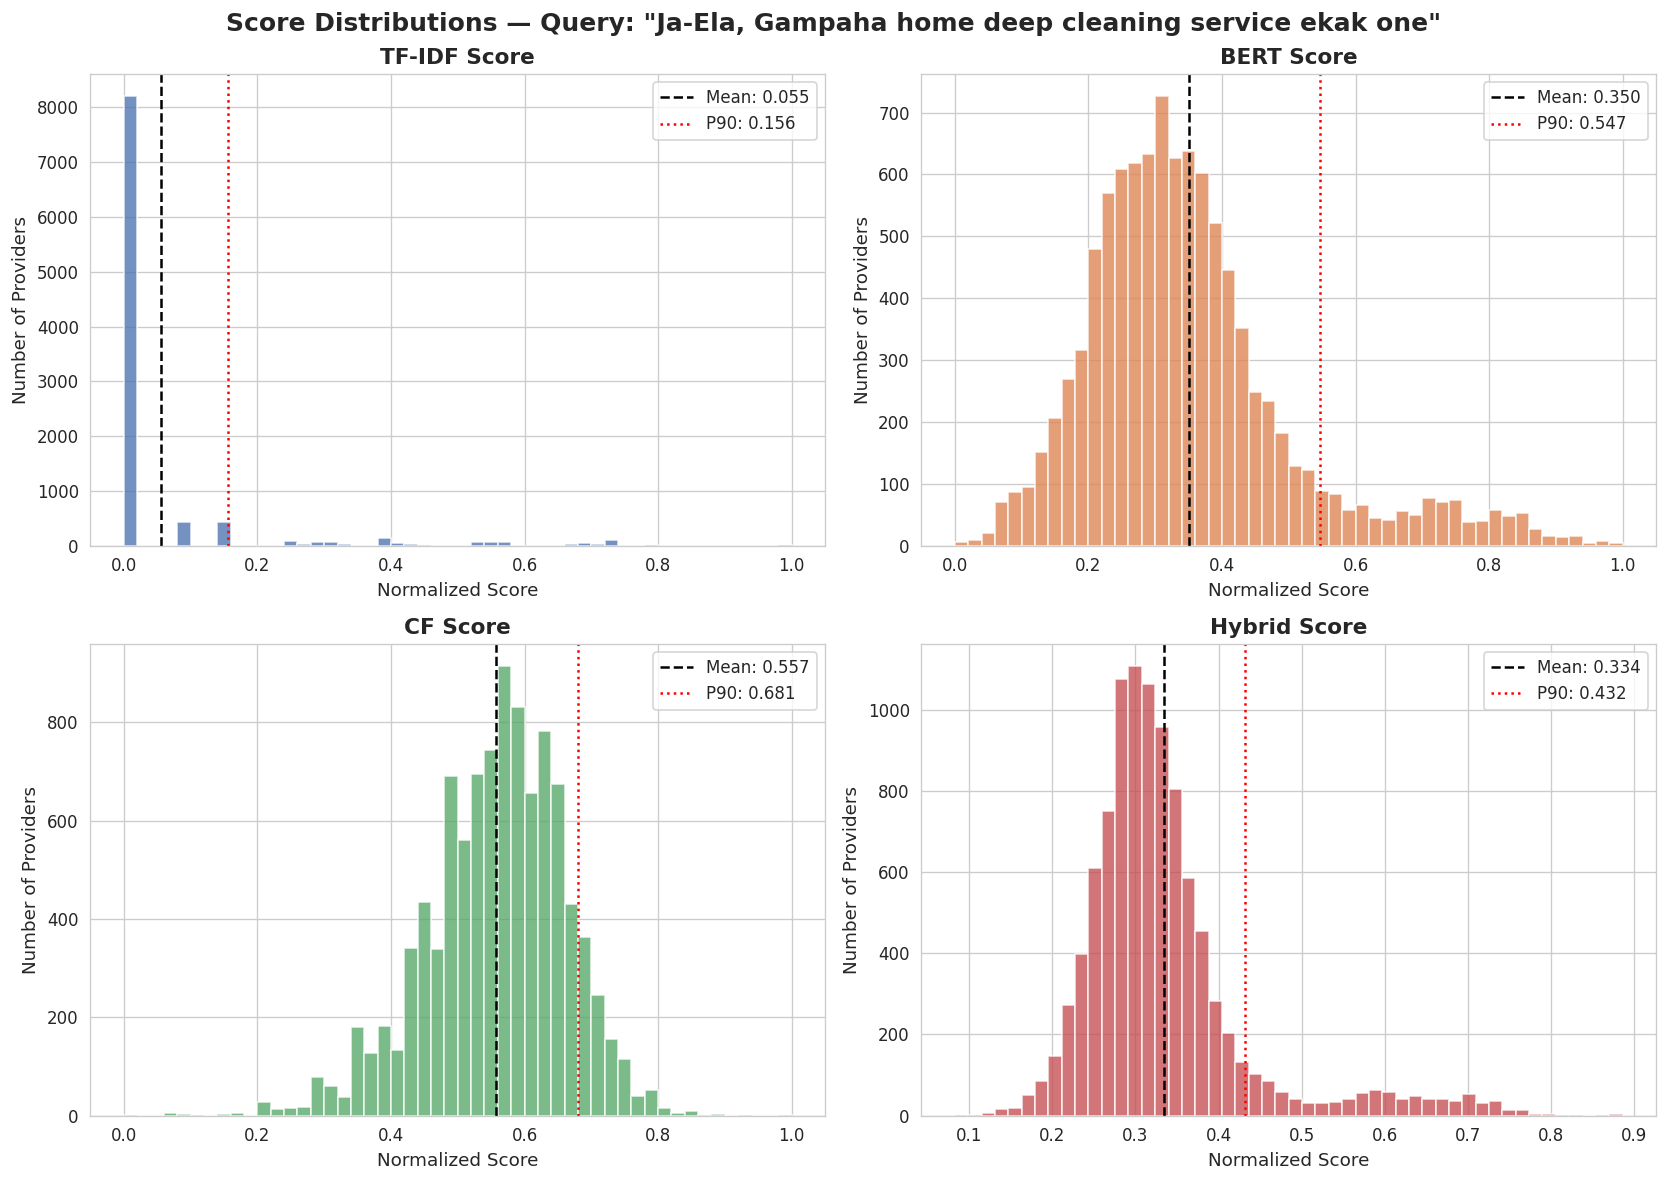

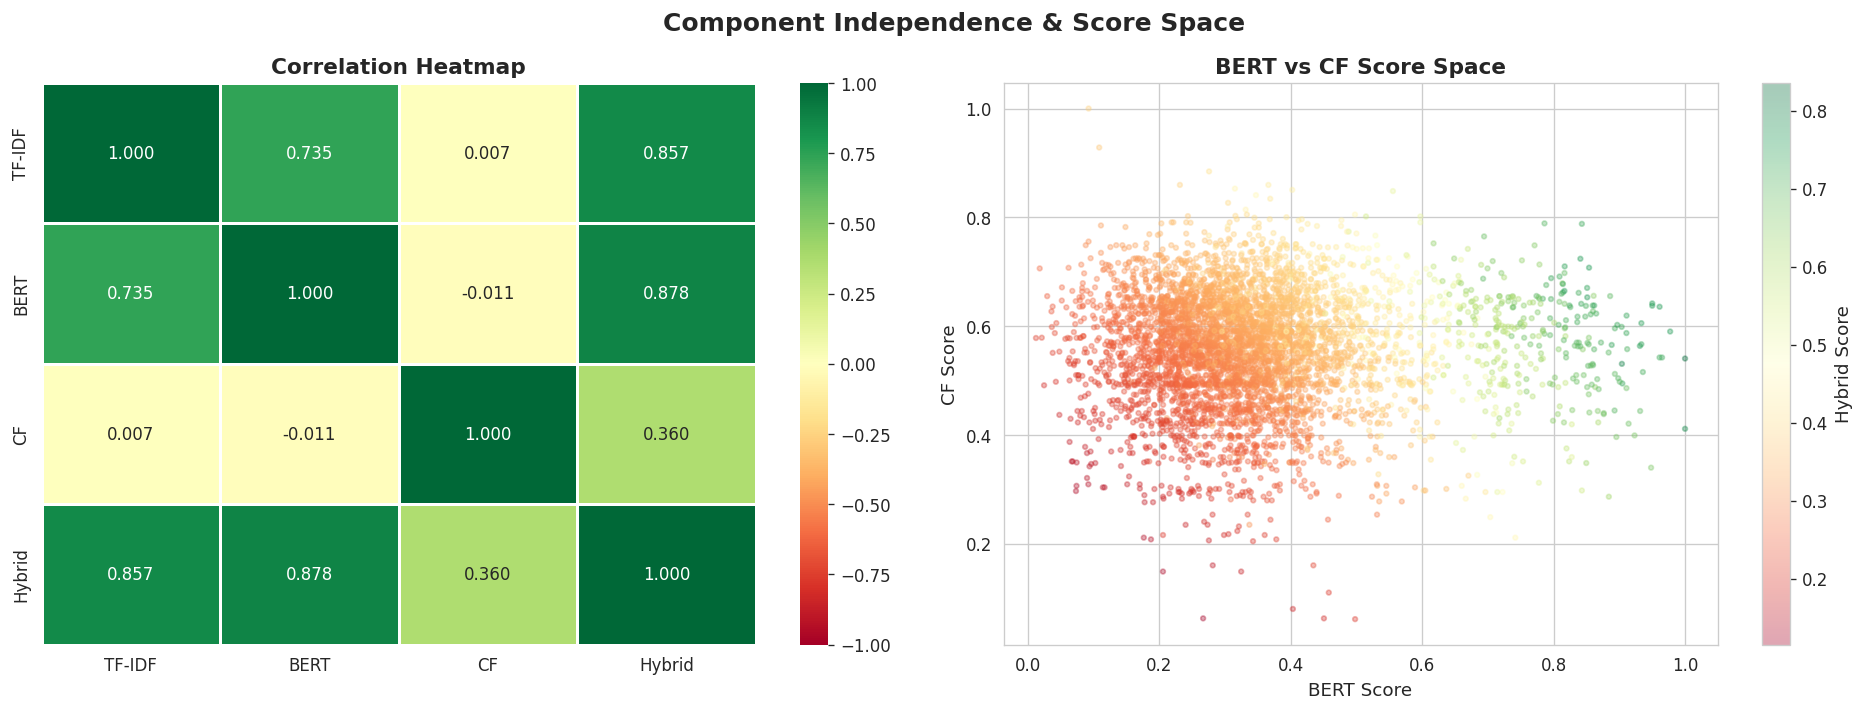

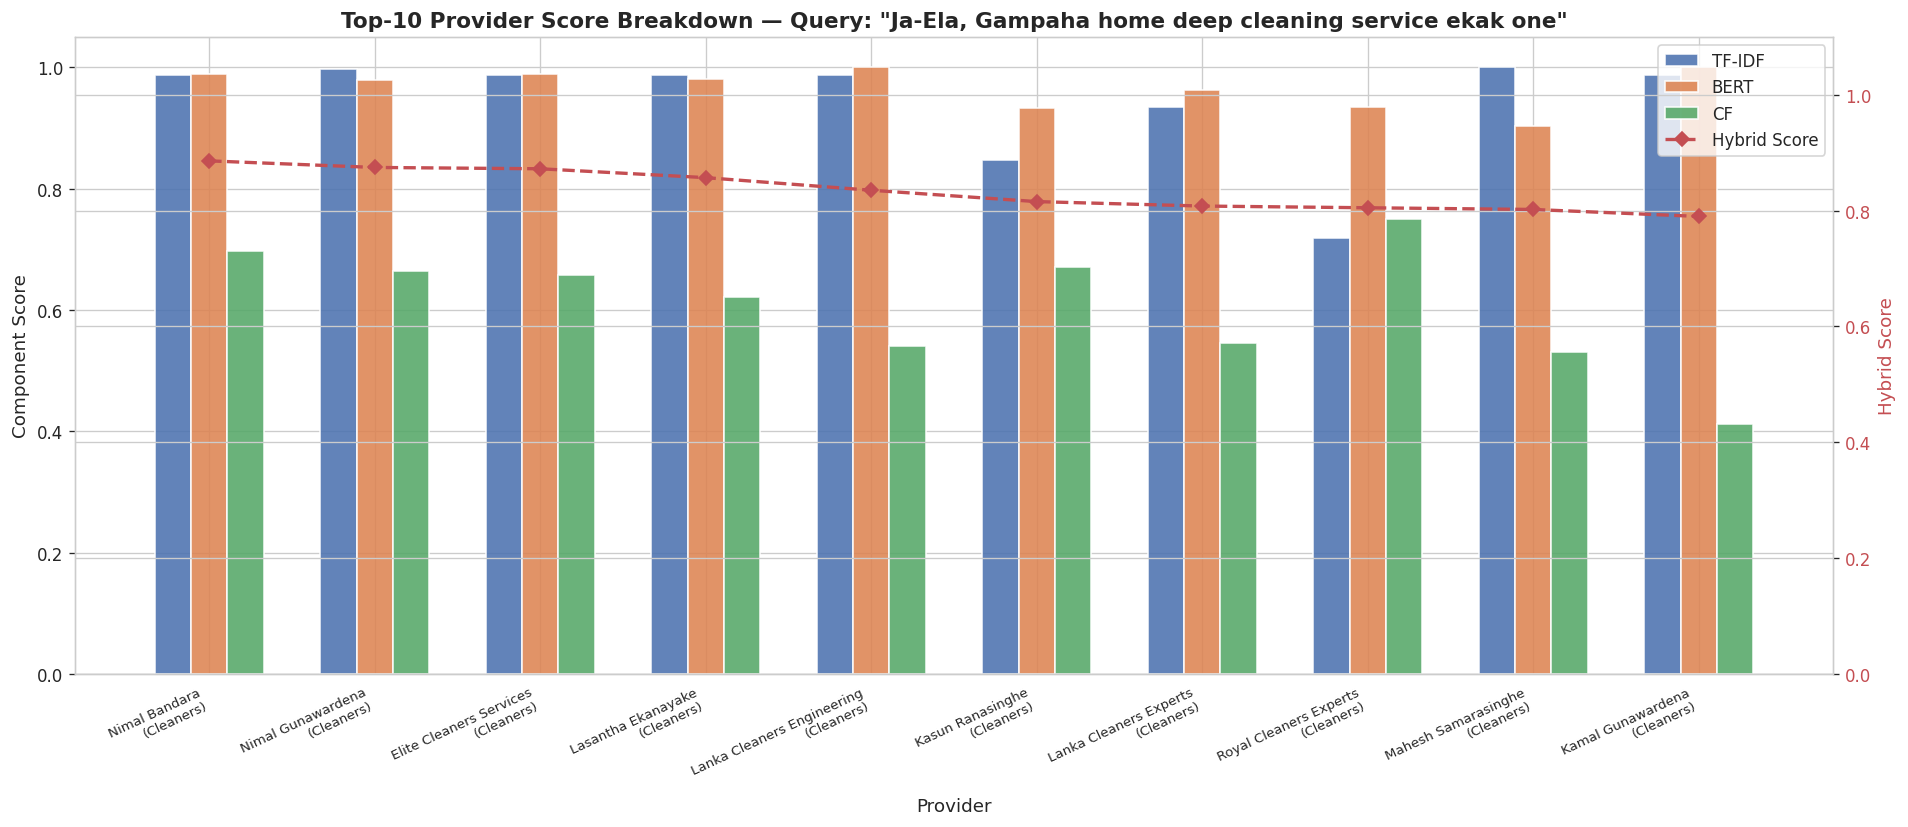

Running weight sensitivity analysis...


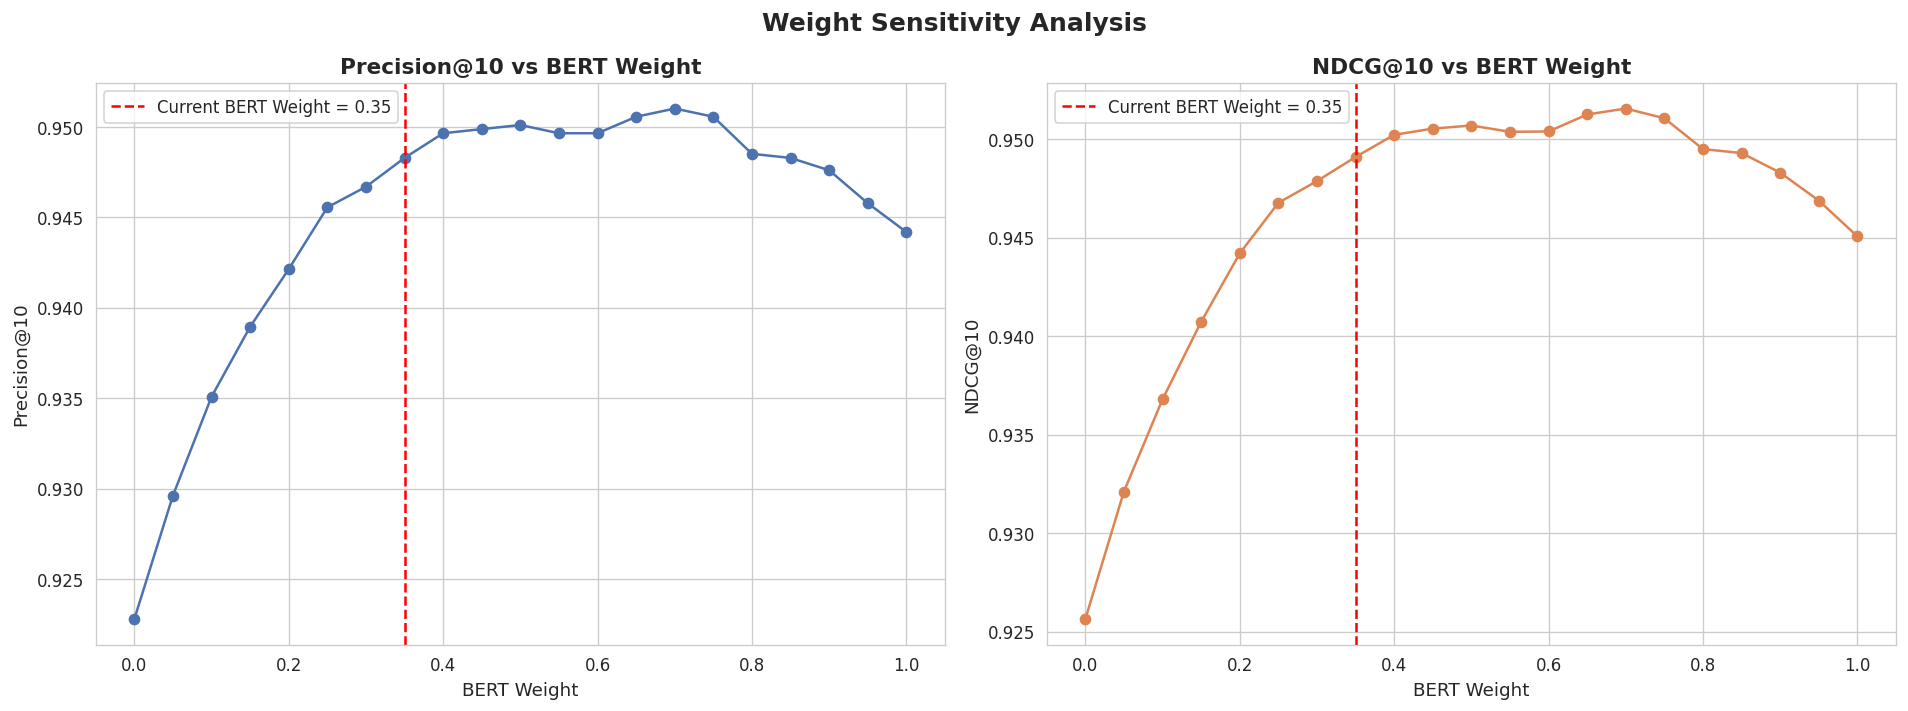

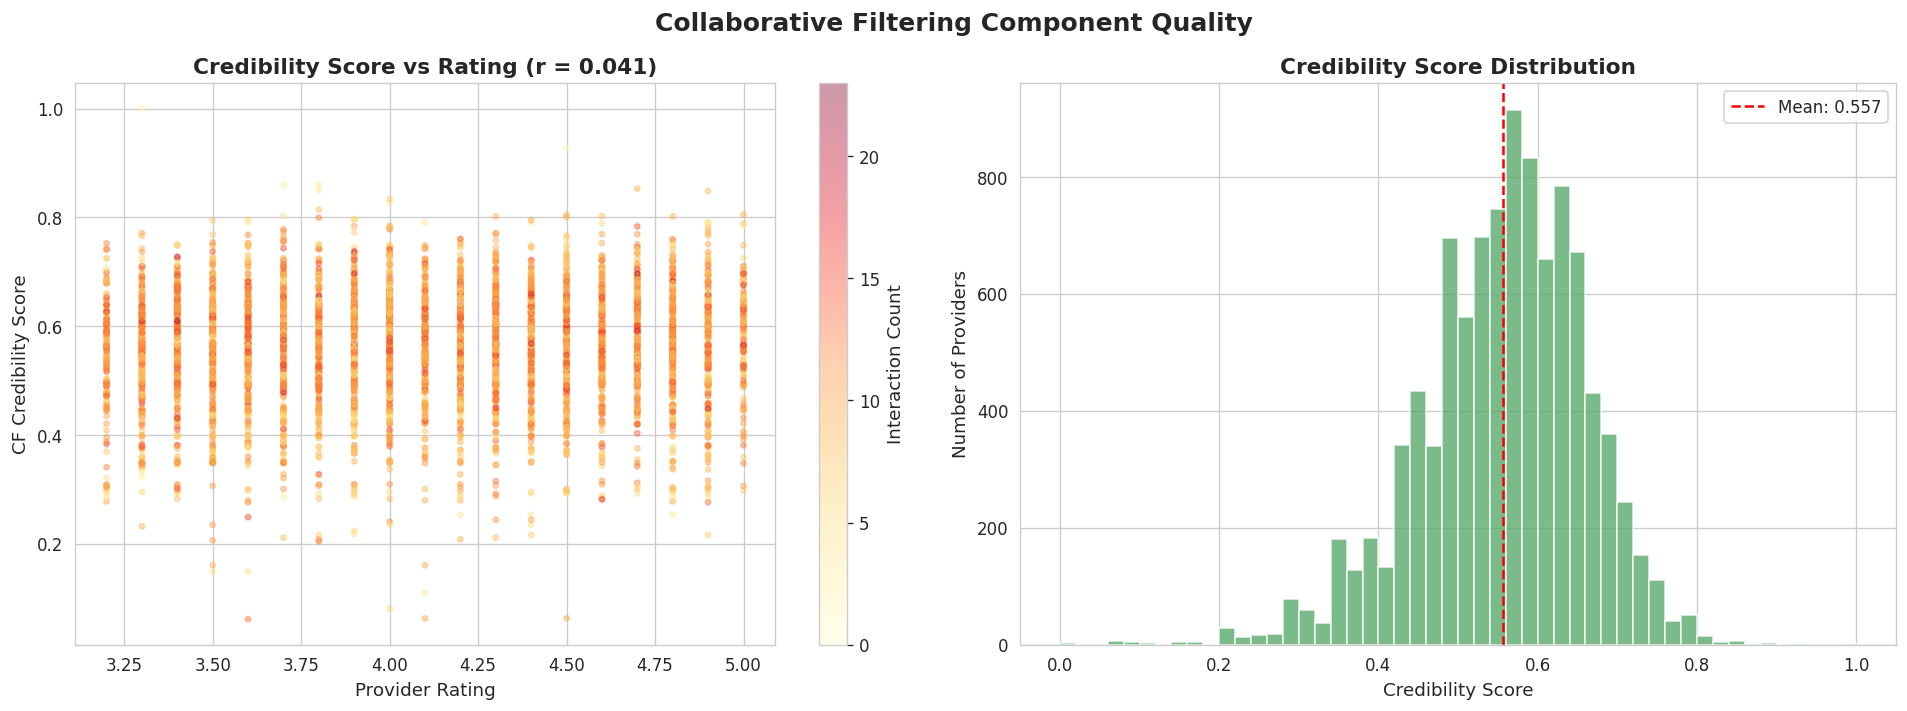

HYBRID RECOMMENDATION SYSTEM — ACCURACY SUMMARY


,Method,P@5,P@10,P@20,NDCG@5,NDCG@10,NDCG@20
0,TF-IDF Only,0.9458,0.9378,0.9231,0.9471,0.9412,0.9297
1,BERT Only,0.9467,0.9442,0.9387,0.9469,0.9451,0.9410
2,CF Only,0.0633,0.0651,0.0672,0.0613,0.0633,0.0654
3,Hybrid,0.9490,0.9483,0.9442,0.9496,0.9490,0.9458



Saved files:
precision_ndcg_comparison.png
score_distributions.png
component_correlation.png
top10_breakdown.png
weight_sensitivity.png
cf_quality_analysis.png
accuracy_summary.csv


In [23]:
# ============================================================
# Accuracy Evaluation & Visualizations
# Purpose: Prove Hybrid model performs better than TF-IDF, BERT, CF alone
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})
sns.set_style("whitegrid")

K_VALUES = [5, 10, 20]

METHODS = {
    "TF-IDF Only": {"tfidf": 1.0, "bert": 0.0, "cf": 0.0},
    "BERT Only": {"tfidf": 0.0, "bert": 1.0, "cf": 0.0},
    "CF Only": {"tfidf": 0.0, "bert": 0.0, "cf": 1.0},
    "Hybrid": WEIGHTS.copy()
}

def precision_at_k(ranked_df, relevant_categories, k):
    return ranked_df.head(k)["category"].isin(relevant_categories).mean()

def ndcg_at_k(ranked_df, relevant_categories, k):
    rel = ranked_df.head(k)["category"].isin(relevant_categories).astype(int).values
    dcg = sum(r / np.log2(i + 2) for i, r in enumerate(rel))

    total_relevant = provider_df["category"].isin(relevant_categories).sum()
    idcg = sum(1 / np.log2(i + 2) for i in range(min(total_relevant, k)))

    return dcg / idcg if idcg > 0 else 0

# ------------------------------------------------------------
# Build robust QUERY_RELEVANCE if not already created
# ------------------------------------------------------------
if "QUERY_RELEVANCE" not in globals() or len(QUERY_RELEVANCE) == 0:
    num_eval_queries = 500

    eval_request_df = request_df.sample(
        n=min(num_eval_queries, len(request_df)),
        random_state=42
    ).reset_index(drop=True)

    QUERY_RELEVANCE = {
        row["request_text"]: [row["category"]]
        for _, row in eval_request_df.iterrows()
    }

print(f"Evaluation queries: {len(QUERY_RELEVANCE)}")

# ------------------------------------------------------------
# Pre-cache scores
# ------------------------------------------------------------
print("Pre-caching component scores...")

cached_eval = {}

for query in QUERY_RELEVANCE:
    cached_eval[query] = {
        "tfidf": normalize_scores(compute_tfidf_scores(query)),
        "bert": normalize_scores(compute_bert_scores(query)),
        "cf": normalize_scores(compute_cf_scores(test_user_id))
    }

print(f"Scores cached for {len(cached_eval)} evaluation queries")

# ------------------------------------------------------------
# 1. Precision@K and NDCG@K
# ------------------------------------------------------------
precision_res = {m: {k: [] for k in K_VALUES} for m in METHODS}
ndcg_res = {m: {k: [] for k in K_VALUES} for m in METHODS}

for query, relevant_categories in QUERY_RELEVANCE.items():
    s = cached_eval[query]

    for method, w in METHODS.items():
        score = (
            w["tfidf"] * s["tfidf"] +
            w["bert"] * s["bert"] +
            w["cf"] * s["cf"]
        )

        temp_df = provider_df[["provider_id", "category"]].copy()
        temp_df["score"] = score
        temp_df = temp_df.sort_values("score", ascending=False).reset_index(drop=True)

        for k in K_VALUES:
            precision_res[method][k].append(
                precision_at_k(temp_df, relevant_categories, k)
            )
            ndcg_res[method][k].append(
                ndcg_at_k(temp_df, relevant_categories, k)
            )

avg_p = {m: {k: np.mean(precision_res[m][k]) for k in K_VALUES} for m in METHODS}
avg_ndcg = {m: {k: np.mean(ndcg_res[m][k]) for k in K_VALUES} for m in METHODS}

method_names = list(METHODS.keys())
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

x = np.arange(len(K_VALUES))
width = 0.18

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Retrieval Quality: Hybrid vs Individual Components", fontsize=15, fontweight="bold")

for ax_idx, (metric_dict, title, ylabel) in enumerate([
    (avg_p, "Precision@K", "Precision"),
    (avg_ndcg, "NDCG@K", "NDCG")
]):
    ax = axes[ax_idx]

    for i, (method, color) in enumerate(zip(method_names, colors)):
        values = [metric_dict[method][k] for k in K_VALUES]
        bars = ax.bar(
            x + (i - 1.5) * width,
            values,
            width,
            label=method,
            color=color,
            alpha=0.88
        )

        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{value:.2f}",
                ha="center",
                fontsize=8,
                fontweight="bold"
            )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Top-K")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels([f"@{k}" for k in K_VALUES])
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("precision_ndcg_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

# ------------------------------------------------------------
# 2. Score Distributions
# ------------------------------------------------------------

eval_query = list(cached_eval.keys())[0]
print("Visualization Query:", eval_query)

s = cached_eval[eval_query]

hybrid_s = (
    WEIGHTS["tfidf"] * s["tfidf"] +
    WEIGHTS["bert"] * s["bert"] +
    WEIGHTS["cf"] * s["cf"]
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Score Distributions — Query: "{eval_query}"', fontsize=15, fontweight="bold")

panels = [
    (s["tfidf"], "TF-IDF Score", "#4C72B0", axes[0, 0]),
    (s["bert"], "BERT Score", "#DD8452", axes[0, 1]),
    (s["cf"], "CF Score", "#55A868", axes[1, 0]),
    (hybrid_s, "Hybrid Score", "#C44E52", axes[1, 1])
]

for scores, title, color, ax in panels:
    ax.hist(scores, bins=50, color=color, alpha=0.78, edgecolor="white")
    ax.axvline(
        scores.mean(),
        color="black",
        linestyle="--",
        label=f"Mean: {scores.mean():.3f}"
    )
    ax.axvline(
        np.percentile(scores, 90),
        color="red",
        linestyle=":",
        label=f"P90: {np.percentile(scores, 90):.3f}"
    )
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Normalized Score")
    ax.set_ylabel("Number of Providers")
    ax.legend()

plt.tight_layout()
plt.savefig("score_distributions.png", bbox_inches="tight", dpi=150)
plt.show()

# ------------------------------------------------------------
# 3. Correlation Heatmap
# ------------------------------------------------------------

score_df = pd.DataFrame({
    "TF-IDF": s["tfidf"],
    "BERT": s["bert"],
    "CF": s["cf"],
    "Hybrid": hybrid_s
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Component Independence & Score Space", fontsize=15, fontweight="bold")

corr = score_df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.8,
    ax=axes[0]
)
axes[0].set_title("Correlation Heatmap", fontweight="bold")

sample = score_df.sample(min(5000, len(score_df)), random_state=42)

scatter = axes[1].scatter(
    sample["BERT"],
    sample["CF"],
    c=sample["Hybrid"],
    cmap="RdYlGn",
    alpha=0.35,
    s=8
)

plt.colorbar(scatter, ax=axes[1], label="Hybrid Score")
axes[1].set_xlabel("BERT Score")
axes[1].set_ylabel("CF Score")
axes[1].set_title("BERT vs CF Score Space", fontweight="bold")

plt.tight_layout()
plt.savefig("component_correlation.png", bbox_inches="tight", dpi=150)
plt.show()

# ------------------------------------------------------------
# 4. Top-10 Provider Score Breakdown
# ------------------------------------------------------------

breakdown_query = eval_query

top10 = rank_providers(
    breakdown_query,
    test_user_id,
    top_k=10
)

labels = [
    f"{row['provider_name']}\n({row['category']})"
    for _, row in top10.iterrows()
]

x = np.arange(len(labels))
w = 0.22

fig, ax = plt.subplots(figsize=(16, 7))

ax.bar(x - w, top10["tfidf_score"], w, label="TF-IDF", color="#4C72B0", alpha=0.88)
ax.bar(x, top10["bert_score"], w, label="BERT", color="#DD8452", alpha=0.88)
ax.bar(x + w, top10["cf_score"], w, label="CF", color="#55A868", alpha=0.88)

ax2 = ax.twinx()
ax2.plot(
    x,
    top10["hybrid_score"],
    "D--",
    color="#C44E52",
    linewidth=2,
    label="Hybrid Score"
)

ax2.set_ylabel("Hybrid Score", color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")
ax2.set_ylim(0, 1.1)

ax.set_title(f'Top-10 Provider Score Breakdown — Query: "{breakdown_query}"', fontweight="bold")
ax.set_xlabel("Provider")
ax.set_ylabel("Component Score")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
ax.set_ylim(0, 1.05)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right")

plt.tight_layout()
plt.savefig("top10_breakdown.png", bbox_inches="tight", dpi=150)
plt.show()

# ------------------------------------------------------------
# 5. Weight Sensitivity Analysis
# ------------------------------------------------------------

print("Running weight sensitivity analysis...")

bert_weights = np.linspace(0, 1, 21)
sens_p10 = []
sens_ndcg10 = []

for bert_w in bert_weights:
    remaining = 1 - bert_w
    tfidf_w = remaining / 2
    cf_w = remaining / 2

    p_values = []
    ndcg_values = []

    for query, relevant_categories in QUERY_RELEVANCE.items():
        s_temp = cached_eval[query]

        score = (
            tfidf_w * s_temp["tfidf"] +
            bert_w * s_temp["bert"] +
            cf_w * s_temp["cf"]
        )

        temp_df = provider_df[["provider_id", "category"]].copy()
        temp_df["score"] = score
        temp_df = temp_df.sort_values("score", ascending=False).reset_index(drop=True)

        p_values.append(precision_at_k(temp_df, relevant_categories, 10))
        ndcg_values.append(ndcg_at_k(temp_df, relevant_categories, 10))

    sens_p10.append(np.mean(p_values))
    sens_ndcg10.append(np.mean(ndcg_values))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Weight Sensitivity Analysis", fontsize=15, fontweight="bold")

axes[0].plot(bert_weights, sens_p10, "o-", color="#4C72B0")
axes[0].axvline(
    WEIGHTS["bert"],
    color="red",
    linestyle="--",
    label=f"Current BERT Weight = {WEIGHTS['bert']}"
)
axes[0].set_title("Precision@10 vs BERT Weight", fontweight="bold")
axes[0].set_xlabel("BERT Weight")
axes[0].set_ylabel("Precision@10")
axes[0].legend()

axes[1].plot(bert_weights, sens_ndcg10, "o-", color="#DD8452")
axes[1].axvline(
    WEIGHTS["bert"],
    color="red",
    linestyle="--",
    label=f"Current BERT Weight = {WEIGHTS['bert']}"
)
axes[1].set_title("NDCG@10 vs BERT Weight", fontweight="bold")
axes[1].set_xlabel("BERT Weight")
axes[1].set_ylabel("NDCG@10")
axes[1].legend()

plt.tight_layout()
plt.savefig("weight_sensitivity.png", bbox_inches="tight", dpi=150)
plt.show()

# ------------------------------------------------------------
# 6. CF Quality Analysis
# ------------------------------------------------------------

cf_df = provider_credibility[["rating", "credibility_score", "interaction_count"]].dropna()
sample_cf = cf_df.sample(min(5000, len(cf_df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Collaborative Filtering Component Quality", fontsize=15, fontweight="bold")

scatter = axes[0].scatter(
    sample_cf["rating"],
    sample_cf["credibility_score"],
    c=sample_cf["interaction_count"],
    cmap="YlOrRd",
    alpha=0.4,
    s=10
)

plt.colorbar(scatter, ax=axes[0], label="Interaction Count")

r_value = sample_cf["rating"].corr(sample_cf["credibility_score"])

axes[0].set_title(
    f"Credibility Score vs Rating (r = {r_value:.3f})",
    fontweight="bold"
)
axes[0].set_xlabel("Provider Rating")
axes[0].set_ylabel("CF Credibility Score")

axes[1].hist(
    provider_credibility["credibility_score"].dropna(),
    bins=50,
    color="#55A868",
    alpha=0.78,
    edgecolor="white"
)

axes[1].axvline(
    provider_credibility["credibility_score"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {provider_credibility['credibility_score'].mean():.3f}"
)

axes[1].set_title("Credibility Score Distribution", fontweight="bold")
axes[1].set_xlabel("Credibility Score")
axes[1].set_ylabel("Number of Providers")
axes[1].legend()

plt.tight_layout()
plt.savefig("cf_quality_analysis.png", bbox_inches="tight", dpi=150)
plt.show()

# ------------------------------------------------------------
# Summary Table
# ------------------------------------------------------------

summary_rows = []

for method in method_names:
    summary_rows.append({
        "Method": method,
        "P@5": round(avg_p[method][5], 4),
        "P@10": round(avg_p[method][10], 4),
        "P@20": round(avg_p[method][20], 4),
        "NDCG@5": round(avg_ndcg[method][5], 4),
        "NDCG@10": round(avg_ndcg[method][10], 4),
        "NDCG@20": round(avg_ndcg[method][20], 4)
    })

summary_df = pd.DataFrame(summary_rows)

print("=" * 90)
print("HYBRID RECOMMENDATION SYSTEM — ACCURACY SUMMARY")
print("=" * 90)

display(summary_df)

summary_df.to_csv("accuracy_summary.csv", index=False)

print("\nSaved files:")
print("precision_ndcg_comparison.png")
print("score_distributions.png")
print("component_correlation.png")
print("top10_breakdown.png")
print("weight_sensitivity.png")
print("cf_quality_analysis.png")
print("accuracy_summary.csv")

## 12. Save output files

In [22]:
top20.to_csv("sample_top20_recommendations.csv", index=False)
eval_df.to_csv("evaluation_results.csv", index=False)
comparison_df.to_csv("method_comparison_results.csv", index=False)

from google.colab import files
files.download("sample_top20_recommendations.csv")
files.download("evaluation_results.csv")
files.download("method_comparison_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes

This notebook keeps your custom CF contribution unchanged.

Main updates compared with your old notebook:
- Uses `category`, `district`, and `city` instead of old `service`, `location`, and `price_lkr`
- Uses three mandatory datasets: providers, user requests, and user interactions
- Removes review dataset dependency because reviews belong to Component 4
- Uses `paraphrase-multilingual-MiniLM-L12-v2` for Sinhala-English semantic matching